In [50]:
!pip install category_encoders

In [51]:
# 1. Data Manipulation dan Umum
import numpy as np
import pandas as pd
from collections import Counter

# 2. Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Preprocessing dan Evaluasi Model
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,

)

# 4. Model Klasifikasi Scikit-learn
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# 5. Model Gradient Boosting Tambahan
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBClassifier

# 6. Penanganan Data Tidak Seimbang (Imbalanced-learn)
# from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

# 7. Category Encoders
import category_encoders as ce

# Tambahan jika diperlukan
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LassoCV


# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score
# from sklearn.model_selection import cross_val_score

In [52]:
df_read = pd.read_csv('/kaggle/input/rtadatasetclean/cleanedfix2.csv')

In [53]:
df_read.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12296 entries, 0 to 12295
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12296 non-null  object
 1   Age_band_of_driver           12296 non-null  object
 2   Sex_of_driver                12296 non-null  object
 3   Vehicle_driver_relation      12296 non-null  object
 4   Driving_experience           12296 non-null  object
 5   Type_of_vehicle              12296 non-null  object
 6   Owner_of_vehicle             12296 non-null  object
 7   Area_accident_occured        12296 non-null  object
 8   Lanes_or_Medians             12296 non-null  object
 9   Road_allignment              12296 non-null  object
 10  Types_of_Junction            12296 non-null  object
 11  Road_surface_type            12296 non-null  object
 12  Road_surface_conditions      12296 non-null  object
 13  Light_conditions             12

In [54]:
df_read.isnull().sum()

Time                           0
Age_band_of_driver             0
Sex_of_driver                  0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_severity              0
Cause_of_accident              0
Accident_severity              0
Day                            0
dtype: int64

In [55]:
df_read.iloc[0:5, 0:7]

,Time,Age_band_of_driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle
0,17:00:00,18-30,Male,Employee,1-2yr,Private Vehicle,Owner
1,17:00:00,31-50,Male,Employee,Above 10yr,Public Transport,Owner
2,17:00:00,18-30,Male,Employee,1-2yr,Commercial Vehicle,Owner
3,01:00:00,18-30,Male,Employee,5-10yr,Public Transport,Governmental
4,01:00:00,18-30,Male,Employee,2-5yr,Private Vehicle,Owner


In [56]:
df_read.iloc[0:5, 7:14]

,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions
0,Residential areas,Two-way (divided with broken lines road marking),Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight
1,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight
2,Recreational areas,other,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight
3,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit
4,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit


In [57]:
df_read.iloc[0:5, 14:23]

,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_severity,Cause_of_accident,Accident_severity,Day
0,Normal,Stationary Object Collision,2,2,Moving forward,na,Moving Backward,Slight Injury,Monday
1,Normal,Vehicle Collision,2,2,Moving forward,na,Speeding,Slight Injury,Monday
2,Normal,Stationary Object Collision,2,2,Moving forward,3,Unsafe Lane Change,Serious Injury,Monday
3,Normal,Vehicle Collision,2,2,Moving forward,3,Unsafe Lane Change,Slight Injury,Sunday
4,Normal,Vehicle Collision,2,2,Moving forward,na,Speeding,Slight Injury,Sunday


buat mix

    Time : KFOLD
    Age  : Label
    Sex_of_drive  : One hot
    vehicle driver realtion : One hot
    Driving expe : Label
    Type of vehicle : kfold target
    Owner of vehicle :  One hot
    Area accident occured : Kfold
    Lanes_or_Medians : Kfold
    Road_allignment : Kfold
    Types of Junction : Kfold
    Road_surface : Ohe
    Road_surface_conditions : ohe
    Light conditions : ohe
    Weather conditions : kfold
    Type of colision : Kfold
    Vehicle Movement : Kfold
    Casualty_severity : Kfold / Label (cek lebih lanjut)
    Cause of accident : Kfold
    Day : Ohe





In [58]:
df_read.iloc[0:5, 14:23]

,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_severity,Cause_of_accident,Accident_severity,Day
0,Normal,Stationary Object Collision,2,2,Moving forward,na,Moving Backward,Slight Injury,Monday
1,Normal,Vehicle Collision,2,2,Moving forward,na,Speeding,Slight Injury,Monday
2,Normal,Stationary Object Collision,2,2,Moving forward,3,Unsafe Lane Change,Serious Injury,Monday
3,Normal,Vehicle Collision,2,2,Moving forward,3,Unsafe Lane Change,Slight Injury,Sunday
4,Normal,Vehicle Collision,2,2,Moving forward,na,Speeding,Slight Injury,Sunday


In [59]:
fitur_kategori = df_read.columns[df_read.dtypes == 'object'].tolist()
fitur_kategori

['Time',
 'Age_band_of_driver',
 'Sex_of_driver',
 'Vehicle_driver_relation',
 'Driving_experience',
 'Type_of_vehicle',
 'Owner_of_vehicle',
 'Area_accident_occured',
 'Lanes_or_Medians',
 'Road_allignment',
 'Types_of_Junction',
 'Road_surface_type',
 'Road_surface_conditions',
 'Light_conditions',
 'Weather_conditions',
 'Type_of_collision',
 'Vehicle_movement',
 'Casualty_severity',
 'Cause_of_accident',
 'Accident_severity',
 'Day']

In [60]:
df_read['Accident_severity'].value_counts()

Accident_severity
Slight Injury     10401
Serious Injury     1737
Fatal injury        158
Name: count, dtype: int64

In [61]:
df_read.isnull().sum()

Time                           0
Age_band_of_driver             0
Sex_of_driver                  0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_severity              0
Cause_of_accident              0
Accident_severity              0
Day                            0
dtype: int64

# Encoding

# Ohe

In [62]:
df_ohe = df_read.copy()

le_target = LabelEncoder()
df_ohe['Accident_severity'] = le_target.fit_transform(df_ohe['Accident_severity'])

categorical_features = df_ohe.select_dtypes(include=['object','category']).columns.tolist()

ohe = OneHotEncoder(sparse_output=False)
ohe_encoded = ohe.fit_transform(df_ohe[categorical_features])

ohe_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(categorical_features))

df_ohe.drop(columns=categorical_features, inplace=True)
df_ohe = pd.concat([df_ohe, ohe_df], axis=1)

df_ohe.head()


,Number_of_vehicles_involved,Number_of_casualties,Accident_severity,Time_00:00:00,Time_01:00:00,Time_02:00:00,Time_03:00:00,Time_04:00:00,Time_05:00:00,Time_06:00:00,...,Cause_of_accident_Speeding,Cause_of_accident_Unknown,Cause_of_accident_Unsafe Lane Change,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,2,2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [63]:
df_ohe.dropna(axis=0, inplace=True)

In [64]:
X_ohe = df_ohe.drop(columns=['Accident_severity'])
y_ohe = df_ohe['Accident_severity']

X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y_ohe, test_size=0.2, random_state=42, stratify=y_ohe)

# KFOLD

In [65]:
from sklearn.model_selection import KFold

df_kfold = df_read.copy()

if df_kfold['Accident_severity'].dtype == 'object':
    le_target = LabelEncoder()
    df_kfold['Accident_severity'] = le_target.fit_transform(df_kfold['Accident_severity'])


kf = KFold(n_splits=5, shuffle=True, random_state=42)

df_kfold_encoded = df_kfold.copy()

for col in categorical_features:
    df_kfold_encoded[col + '_kfold'] = 0

    for train_idx, val_idx in kf.split(df_kfold_encoded):
        encoder = ce.TargetEncoder(
            cols=[col],
            smoothing=1,
            min_samples_leaf=5
        )

        df_kfold_encoded.loc[train_idx, col + '_kfold'] = encoder.fit_transform(df_kfold_encoded.loc[train_idx, [col]], df_kfold_encoded.loc[train_idx, 'Accident_severity']).iloc[:, 0]

        df_kfold_encoded.loc[val_idx, col + '_kfold'] = encoder.transform(df_kfold_encoded.loc[val_idx, [col]]).iloc[:, 0]

    df_kfold_encoded.drop(columns=[col], inplace=True)

df_kfold_encoded

df_kfold = df_kfold_encoded



In [66]:
X = df_kfold.drop(columns=['Accident_severity'])
y = df_kfold['Accident_severity']

X_train_kfold, X_test_kfold, y_train_kfold, y_test_kfold = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Selection

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA

target_column = 'Accident_severity'
corr_matrix = df_ohe.corr()
target_corr = corr_matrix[target_column].abs().sort_values(ascending=False)
selected_features_corr_ohe = target_corr[target_corr > 0.05].index.tolist()
selected_features_corr_ohe.remove(target_column)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(rf, n_features_to_select=10)
rfe.fit(X_train_ohe, y_train_ohe)
selected_features_rfe_ohe = X_train_ohe.columns[rfe.support_].tolist()

lasso = LassoCV(cv=5, random_state=42).fit(X_train_ohe, y_train_ohe)
model = SelectFromModel(lasso, prefit=True)
selected_features_lasso_ohe = X_train_ohe.columns[model.get_support()].tolist()

pca = PCA(n_components=0.95, random_state=42)
X_train_pca_ohe = pca.fit_transform(X_train_ohe)
X_test_pca_ohe = pca.transform(X_test_ohe)

len(selected_features_corr_ohe), len(selected_features_rfe_ohe), len(selected_features_lasso_ohe), X_train_pca_ohe.shape[1]


(2, 10, 44, 72)

In [68]:
target_column = 'Accident_severity'
corr_matrix = df_kfold.corr()
target_corr = corr_matrix[target_column].abs().sort_values(ascending=False)
selected_features_corr_kfold = target_corr[target_corr > 0.05].index.tolist()
selected_features_corr_kfold.remove(target_column)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(rf, n_features_to_select=10)
rfe.fit(X_train_kfold, y_train_kfold)
selected_features_rfe_kfold = X_train_kfold.columns[rfe.support_].tolist()

lasso = LassoCV(cv=5, random_state=42).fit(X_train_kfold, y_train_kfold)
model = SelectFromModel(lasso, prefit=True)
selected_features_lasso_kfold = X_train_kfold.columns[model.get_support()].tolist()

pca = PCA(n_components=0.95, random_state=42)
X_train_pca_kfold = pca.fit_transform(X_train_kfold)
X_test_pca_kfold = pca.transform(X_test_kfold)

len(selected_features_corr_kfold), len(selected_features_rfe_kfold), len(selected_features_lasso_kfold), X_train_pca_kfold.shape[1]



(4, 10, 19, 2)

# Imbalance data

In [69]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

# DataFrame global untuk menyimpan hasil evaluasi
# evaluation_results = pd.DataFrame(columns=['model_type', 'method', 'technique', 'f1_score_weighted', 'accuracy', 'precision', 'recall'])

def resample(X_train, y_train, method='smote', random_state=42, k_neighbors=5):
    """
    Fungsi untuk melakukan resampling dataset untuk klasifikasi multi-class.

    Parameters:
    - X_train: Fitur data pelatihan
    - y_train: Label target pelatihan
    - method: Metode resampling yang digunakan ('smote', 'smote_tomek', 'weighted')
    - random_state: Random seed untuk reprodusibilitas
    - k_neighbors: Jumlah tetangga terdekat untuk SMOTE (default=5)

    Returns:
    - X_train_resampled: Fitur data pelatihan setelah resampling
    - y_train_resampled: Label target pelatihan setelah resampling
    - sample_weights: Bobot sampel (hanya jika 'weighted' dipilih)
    """
    if method == 'smote':
        print("Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.")
        class_counts = np.bincount(y_train)
        majority_class_count = max(class_counts)
        sampling_strategy = {class_label: majority_class_count // 2 if count < majority_class_count else count
                             for class_label, count in enumerate(class_counts)}

        smote = SMOTE(sampling_strategy=sampling_strategy, random_state=random_state, k_neighbors=k_neighbors)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    elif method == 'smote_tomek':
        print("Resampling menggunakan SMOTE-Tomek.")
        smote_tomek = SMOTETomek(random_state=random_state)
        X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)

    elif method == 'weighted':
        print("Resampling dengan weighted sampling berdasarkan model.")
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        X_train_resampled, y_train_resampled = X_train, y_train
        return X_train_resampled, y_train_resampled, sample_weights

    else:
        raise ValueError("Metode resampling tidak dikenali. Pilih antara 'smote', 'smote_tomek', atau 'weighted'.")

    return X_train_resampled, y_train_resampled, None


import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, precision_score, recall_score, balanced_accuracy_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

# DataFrame global untuk menyimpan hasil evaluasi
evaluation_results2 = pd.DataFrame(columns=['model_type', 'method', 'technique',
                                           'f1_weighted', 'accuracy', 'precision', 'recall',
                                           'f1_micro', 'f1_macro', 'balanced_accuracy', 'roc_auc'])

def train_and_evaluate_model(X_train, y_train, X_test, y_test, model_type='xgboost', method='smote', technique='all features', random_state=42, k_neighbors=5):
    """
    Fungsi untuk melatih dan mengevaluasi model dengan tambahan metrik evaluasi.
    """

    # Lakukan resampling
    X_train_resampled, y_train_resampled, sample_weights = resample(X_train, y_train, method=method, random_state=random_state, k_neighbors=k_neighbors)

    # Pilih model berdasarkan parameter model_type
    if model_type == 'xgboost':
        model = xgb.XGBClassifier(random_state=random_state, n_jobs=-1)
    elif model_type == 'randomforest':
        model = RandomForestClassifier(random_state=random_state, n_jobs=-1)
    elif model_type == 'extratrees':
        model = ExtraTreesClassifier(random_state=random_state, n_jobs=-1)
    elif model_type == 'knn':
        model = KNeighborsClassifier(n_jobs=-1)
    elif model_type == 'logreg':
        model = LogisticRegression(random_state=random_state, n_jobs=-1)
    else:
        raise ValueError("Model tidak dikenali. Pilih antara 'xgboost', 'randomforest', 'extratrees', 'knn', atau 'logreg'.")

    # Latih model
    if model_type in ['knn']:
        model.fit(X_train_resampled, y_train_resampled)  # KNN tidak mendukung sample_weight
    else:
        model.fit(X_train_resampled, y_train_resampled, sample_weight=sample_weights)

    # Prediksi dan evaluasi model pada data uji
    y_pred = model.predict(X_test)

    # Metrik evaluasi
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # ROC-AUC Per Kelas (hanya jika model mendukung probabilitas)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class="ovr")
    else:
        roc_auc = np.nan  # Tidak dapat dihitung jika model tidak mendukung predict_proba

    # Menambahkan hasil evaluasi ke dalam DataFrame global
    evaluation_results2.loc[len(evaluation_results2)] = [model_type, method, technique,
                                                        f1_weighted, accuracy, precision, recall,
                                                        f1_micro, f1_macro, balanced_acc, roc_auc]

    # Menampilkan hasil evaluasi
    print(f"Model: {model_type}, Metode Resampling: {method}")
    print(f"F1-Score (Weighted): {f1_weighted:.4f}")
    print(f"F1-Score (Micro): {f1_micro:.4f}")
    print(f"F1-Score (Macro): {f1_macro:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"ROC-AUC (One-vs-Rest): {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model, f1_weighted, accuracy, precision, recall, f1_micro, f1_macro, balanced_acc, roc_auc


ohe

In [70]:
!pip install optuna

# RANDOM FOREST

In [ ]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import load_iris


def objective(trial, X_train, y_train):
    n_estimators = trial.suggest_int("n_estimators", 50, 300, step=50)
    max_depth = trial.suggest_int("max_depth", 3, 20, step=1)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        random_state=42,
        warm_start=True
    )

    train_losses = []
    val_losses = []

    for i in range(1, n_estimators + 1):
        model.n_estimators = i
        model.fit(X_train, y_train)

        train_loss = log_loss(y_train_kfold, model.predict_proba(X_train_pca_kfold))
        val_loss = log_loss(y_test_kfold, model.predict_proba(X_test_pca_kfold))

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)

    return val_losses[-1]

[I 2025-03-14 06:50:26,083] A new study created in memory with name: no-name-c041beec-0095-468e-b106-5bb44a621509


Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.


[I 2025-03-14 06:50:53,919] Trial 0 finished with value: 0.6196383611991882 and parameters: {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 0 with value: 0.6196383611991882.
[I 2025-03-14 06:52:03,035] Trial 1 finished with value: 0.5926739460363653 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 2, 'criterion': 'entropy'}. Best is trial 1 with value: 0.5926739460363653.
[I 2025-03-14 06:55:10,920] Trial 5 finished with value: 0.6094431661852993 and parameters: {'n_estimators': 150, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 1 with value: 0.5926739460363653.
[I 2025-03-14 06:55:16,560] Trial 6 finished with value: 0.6917147842212173 and parameters: {'n_estimators': 100, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 2, 'criterion': 'entropy'}. Best is trial 1 with value: 0.5926739460363653.
[


Best Parameters: {'n_estimators': 200, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 5, 'criterion': 'gini'}
Best Validation Loss: 0.5769467545482468

Confusion Matrix:
[[  10    5   17]
 [  19   89  239]
 [ 109  176 1796]]

Test Set Evaluation:
Precision on Test Set: 0.7878383692430874
Recall on Test Set: 0.7703252032520326
F1 Score on Test Set: 0.7774283167151048


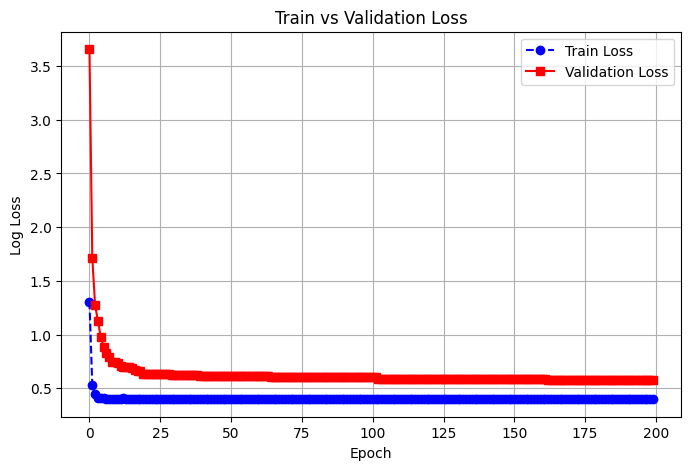

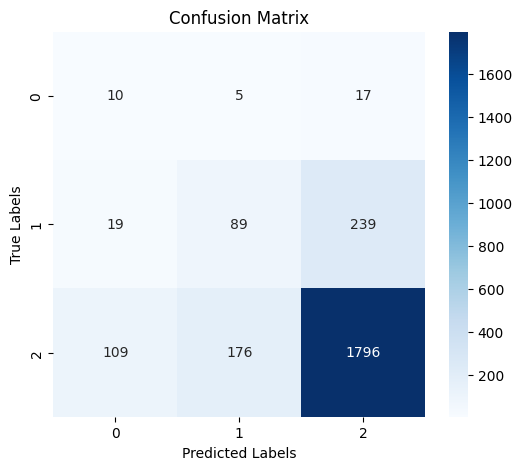

In [43]:


# Training randomforest dengan teknik resampling smote...
# Resampling menggunakan SMOTE dengan rasio 0.5 untuk kelas minoritas.
# Model: randomforest, Metode Resampling: smote
# F1-Score (Weighted): 0.7611
# F1-Score (Micro): 0.7382
# F1-Score (Macro): 0.4275
# Balanced Accuracy: 0.5052
# ROC-AUC (One-vs-Rest): 0.7176
# Accuracy: 0.7382
# Precision: 0.7894
# Recall: 0.7382
# Confusion Matrix:
# [[  12    4   16]
#  [  25  114  208]
#  [ 121  270 1690]]

# Training randomforest dengan teknik resampling smote_tomek...
# Resampling menggunakan SMOTE-Tomek.
# Model: randomforest, Metode Resampling: smote_tomek
# F1-Score (Weighted): 0.7147
# F1-Score (Micro): 0.6654
# F1-Score (Macro): 0.4093
# Balanced Accuracy: 0.5236
# ROC-AUC (One-vs-Rest): 0.7085
# Accuracy: 0.6654
# Precision: 0.7943
# Recall: 0.6654
# Confusion Matrix:
# [[  13    7   12]
#  [  26  160  161]
#  [ 174  443 1464]]
# run_all_models_with_resampling(X_train_pca_kfold, y_train_kfold, X_test_pca_kfold, y_test_kfold, 'PCA (KFOLD)')


X_train_rf1, y_train_rf1, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_rf1, y_train_rf1), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = RandomForestClassifier(
    n_estimators=best_trial.params["n_estimators"],
    max_depth=best_trial.params["max_depth"],
    min_samples_split=best_trial.params["min_samples_split"],
    min_samples_leaf=best_trial.params["min_samples_leaf"],
    criterion=best_trial.params["criterion"],
    random_state=42
)

best_model.fit(X_train_rf1, y_train_rf1)
y_pred = best_model.predict(X_test_pca_kfold)

test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [ ]:

X_train_rf2, y_train_rf2, _ = resample(X_train_pca_kfold, y_train_kfold, method='smote_tomek', random_state=42, k_neighbors=5)
study = optuna.create_study(direction="minimize")
study.optimize(lambda trial: objective(trial, X_train_rf2, y_train_rf2), n_trials=30)

best_trial = study.best_trial

print("\nBest Parameters:", best_trial.params)
print("Best Validation Loss:", best_trial.value)

best_model = RandomForestClassifier(
    n_estimators=best_trial.params["n_estimators"],
    max_depth=best_trial.params["max_depth"],
    min_samples_split=best_trial.params["min_samples_split"],
    min_samples_leaf=best_trial.params["min_samples_leaf"],
    criterion=best_trial.params["criterion"],
    random_state=42
)

best_model.fit(X_train_rf12, y_train_rf12)
y_pred = best_model.predict(X_test_pca_kfold)

test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


[I 2025-03-14 07:18:48,375] A new study created in memory with name: no-name-69b43109-55a6-4f71-bf5f-f2d1fdc493e2


Resampling menggunakan SMOTE-Tomek.


[I 2025-03-14 07:18:56,083] Trial 0 finished with value: 0.854641721964627 and parameters: {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 3, 'criterion': 'entropy'}. Best is trial 0 with value: 0.854641721964627.
[I 2025-03-14 07:19:09,321] Trial 1 finished with value: 0.915328811342033 and parameters: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 0 with value: 0.854641721964627.
[I 2025-03-14 07:19:11,498] Trial 2 finished with value: 0.8867242090247716 and parameters: {'n_estimators': 50, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 0 with value: 0.854641721964627.
[I 2025-03-14 07:19:24,763] Trial 3 finished with value: 0.9153243461952459 and parameters: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 1, 'criterion': 'entropy'}. Best is trial 0 with value: 0.854641721964627.
[I 2025-0


Best Parameters: {'n_estimators': 250, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 5, 'criterion': 'gini'}
Best Validation Loss: 0.7516043183041103


NameError: name 'X_train_rf12' is not defined


Confusion Matrix:
[[  12    8   12]
 [  25  155  167]
 [ 166  506 1409]]

Test Set Evaluation:
Precision on Test Set: 0.7840311302959263
Recall on Test Set: 0.640650406504065
F1 Score on Test Set: 0.6940935137147527


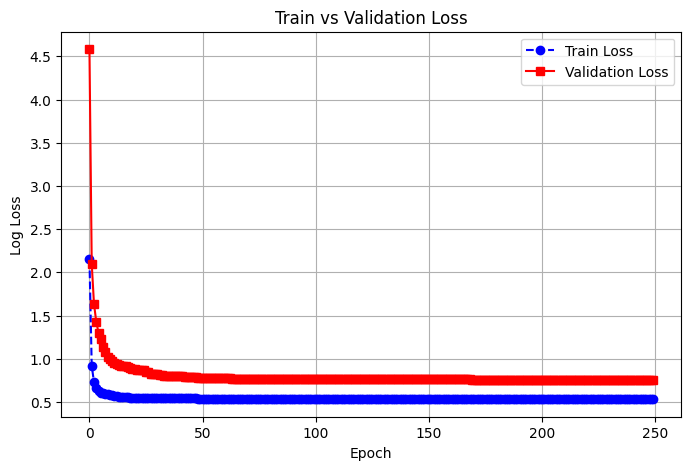

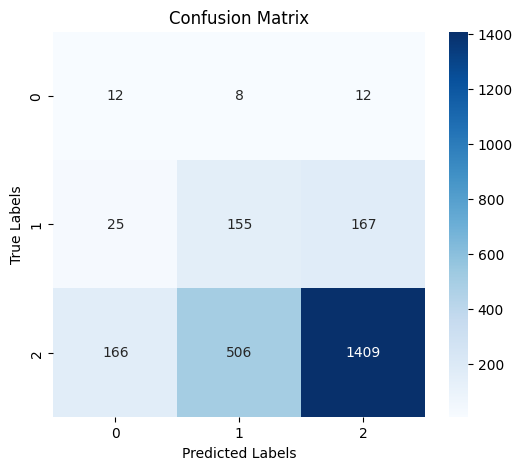

In [46]:
best_model.fit(X_train_rf2, y_train_rf2)
y_pred = best_model.predict(X_test_pca_kfold)

test_precision = precision_score(y_test_kfold, y_pred, average="weighted")
test_recall = recall_score(y_test_kfold, y_pred, average="weighted")
test_f1 = f1_score(y_test_kfold, y_pred, average="weighted")

cm = confusion_matrix(y_test_kfold, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nTest Set Evaluation:")
print("Precision on Test Set:", test_precision)
print("Recall on Test Set:", test_recall)
print("F1 Score on Test Set:", test_f1)

best_train_losses = best_trial.user_attrs["train_losses"]
best_val_losses = best_trial.user_attrs["val_losses"]

plt.figure(figsize=(8, 5))
plt.plot(best_train_losses, label="Train Loss", marker="o", linestyle="--", color="blue")
plt.plot(best_val_losses, label="Validation Loss", marker="s", linestyle="-", color="red")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# Heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
